In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"D:\Projects\Data\Sleep_Work_Productivity_Surve.xlsx")

# clean age column
df['Enter your age ?']= df['Enter your age ?'].fillna(df['Enter your age ?'].median())

# rename the columns
df.rename(columns={
    'How would you rate your overall work productivity?': 'work_productivity',
    'How much do you think your sleep affects your productivity at work?': 'sleep_productivity_effect',
    'What factors do you believe impact your sleep quality? (Select all that apply)': 'sleep_factors',
    'How many breaks do you take during your workday when you are tired ?': 'break_nums',
    'How would you describe your energy levels throughout the workday?': 'energy_levels_per_workday',
    'What is your primary work environment?': 'primary_work_environment',
    'what is you gender ?': 'gender',
    'On a typical work night, how many hours of sleep do you get?': 'sleep_hours',
    
    'I wake up feeling refreshed and ready for work.':
        'wake_up_refreshed',

    'I have difficulty falling asleep the night before an important workday.':
        'difficulty_falling_asleep',

    'Enter your age ?':
        'age',

    'I wake up multiple times during the night and struggle to go back to sleep.':
        'wake_up_multiple_times',

    'On weekends or days off, my sleep schedule is very different from my workday schedule (e.g., sleeping in more than 2 hours later).':
        'weekend_sleep_schedule_difference',

    'I use electronic devices (phone, laptop, TV) in bed within 30 minutes of trying to sleep.':
        'device_use_before_sleep',

    'I find it hard to concentrate on work tasks for more than 15–20 minutes at a time.':
        'difficulty_concentrating',

    'I make careless mistakes (e.g., typos, miscalculations, forgetting steps) that I would not have made if better rested.':
        'careless_mistakes',

    'I often have to re-read emails, documents, or instructions because I lost focus.':
        'reread_due_to_focus_loss',

    'Learning a new software, process, or skill at work feels unusually difficult for me.':
        'difficulty_learning_new_skills',

    'I struggle to generate new ideas or creative solutions to problems.':
        'difficulty_generating_ideas',

    'I forget important tasks, deadlines, or details from meetings.':
        'forget_tasks_deadlines',

    'I feel irritable or short-tempered with colleagues or clients.':
        'irritable_with_colleagues',

    'Small setbacks or minor criticism feel overwhelming or upsetting.':
        'small_setbacks_overwhelming',

    'I avoid collaboration or group work because I feel mentally exhausted.':
        'avoid_collaboration',

    'I have difficulty controlling my emotions during stressful work situations (e.g., tight deadlines, difficult customers).':
        'difficulty_controlling_emotions',

    'I feel physically tired, sluggish, or heavy-eyed during work, even without heavy physical exertion.':
        'physically_tired_at_work',

    'In my job, I have had a close call, minor accident, or injury that I attribute to being too tired. If your job is sedentary, answer based on accidents like tripping, bumping into things, or spilling hot liquids.':
        'accident_due_to_tiredness',

    'Compared to when I am well-rested, I estimate my current work output is...':
        'current_work_output',

    'In the past month, how many work days did you feel you were “present but not productive” (getting less than half of your normal output) due to poor sleep?':
        'unproductive_workdays_due_to_sleep'

}, inplace=True)


# clean the names
df = df.replace(r'\n', ', ', regex=True)
df["sleep_factors"] = df["sleep_factors"].str.split(", ")


# Reverse the only positive-direction question
df['wake_up_refreshed_reverse'] = 6 - df['wake_up_refreshed']


# clean unproductive_workdays_due_to_sleep outlires
df.loc[df["unproductive_workdays_due_to_sleep"] > 23,
       "unproductive_workdays_due_to_sleep"] = np.nan

median = df['unproductive_workdays_due_to_sleep'].median().round(0)
df['unproductive_workdays_due_to_sleep'] = df['unproductive_workdays_due_to_sleep'].fillna(median)


# 1. Sleep Quality and Hygiene Index (SQLI)
# 5 questions × maximum score of 5 = 25
# Divide by 25 and multiply by 100 → maximum possible score = 100
df['sleep_quality_and_hygiene_index_(SQLI)'] = (
    (
        df['wake_up_refreshed_reverse']
        + df['difficulty_falling_asleep']
        + df['wake_up_multiple_times']
        + df['weekend_sleep_schedule_difference']
        + df['device_use_before_sleep']
    ) / 25
) * 100


# 2. Cognitive at-task Performance Index (CTPI)
# 6 questions × maximum score of 5 = 30
# Divide by 30 and multiply by 100 → maximum possible score = 100
df['Cognitive_at_task_perforamnce_index_(CTPI)'] = (
    (df['difficulty_concentrating']
     + df['careless_mistakes']
     + df['reread_due_to_focus_loss']
     + df['difficulty_learning_new_skills']
     + df['difficulty_generating_ideas']
     + df['forget_tasks_deadlines']) / 30
) * 100

df['Cognitive_at_task_perforamnce_index_(CTPI)'] = (
    df['Cognitive_at_task_perforamnce_index_(CTPI)'].round(2)
)


# 3. Emotional and Social Impact Index (ESII)
# 4 questions × maximum score of 5 = 20
# Divide by 20 and multiply by 100 → maximum possible score = 100
df['Emotional_and_social_impact_index(ESII)'] = (
    (df['irritable_with_colleagues']
     + df['small_setbacks_overwhelming']
     + df['avoid_collaboration']
     + df['difficulty_controlling_emotions']) / 20
) * 100


# 4. Physical and Safety Risk Index (PSRI)
# 2 questions × maximum score of 5 = 10
# Divide by 10 and multiply by 100 → maximum possible score = 100
df['Physical_and_safety_risk_index(PSRI)'] = (
    (df['physically_tired_at_work']
     + df['accident_due_to_tiredness']) / 10
) * 100


# 5. Presentative Index (PI)
output_loss_map = {
    'About the same or better': 0.00,
    '20–40% less': 0.30,
    '40–60% less': 0.50,
    '60–80% less': 0.70,
    '80–100% less':1.00
}

df['productivity_loss_fraction'] = (
    df['current_work_output'].map(output_loss_map)
)

df['Presentative_index(PI)'] = (
    (df['unproductive_workdays_due_to_sleep'] / 23)
    * df['productivity_loss_fraction']
    * 100
)

df['Presentative_index(PI)'] = (
    df['Presentative_index(PI)'].round(2)
)


# 6. Overall Sleep Productivity Impact Index (SPI)
# Each component has a maximum of 100.
# Therefore, their total maximum = 400.
# Dividing by 4 gives an average with a maximum of 100.
df['Overall_sleep_Productivity_Impact_index(SPI)'] = (
    df['Cognitive_at_task_perforamnce_index_(CTPI)']
    + df['Emotional_and_social_impact_index(ESII)']
    + df['Physical_and_safety_risk_index(PSRI)']
    + df['Presentative_index(PI)']
) / 4

## **The Qs We Are Going To Answer, Using ML Models**

### ML 1 — SPI
- Can we predict overall sleep-related productivity impact (categorized) from workers' sleep, work, and demographic characteristics.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Submission Date                               127 non-null    str    
 1   work_productivity                             127 non-null    str    
 2   sleep_productivity_effect                     127 non-null    str    
 3   sleep_factors                                 127 non-null    object 
 4   break_nums                                    122 non-null    str    
 5   energy_levels_per_workday                     127 non-null    str    
 6   primary_work_environment                      125 non-null    str    
 7   gender                                        127 non-null    str    
 8   sleep_hours                                   127 non-null    str    
 9   wake_up_refreshed                             127 non-null    int64  
 10  d

In [4]:
numeric_columns = df.select_dtypes(include='number').columns.tolist()

In [5]:
cols_to_remove = ['wake_up_refreshed',
    'sleep_quality_and_hygiene_index_(SQLI)',
    'Cognitive_at_task_perforamnce_index_(CTPI)',
    'Emotional_and_social_impact_index(ESII)',
    'Physical_and_safety_risk_index(PSRI)',
    'Presentative_index(PI)',
    'Overall_sleep_Productivity_Impact_index(SPI)'
]

numeric_columns = [col for col in numeric_columns if col not in cols_to_remove]

In [6]:
ordinal_columns = [
    "work_productivity",
    "sleep_productivity_effect",
    "break_nums",
    "energy_levels_per_workday",
    "sleep_hours"
]

In [7]:
nominal_columns = [
    "primary_work_environment",
    "gender"
]

In [8]:
ordinal_categories = [
    [
        "Low",
        "Moderate",
        "High",
        "Very high"
    ],

    [
        "Not at all",
        "A little",
        "Moderately",
        "Significantly",
        "Extremely"
    ],

    [
        "1-2",
        "3-4",
        "5 or more"
    ],

    [
        "Very low",
        "Low",
        "Moderate",
        "High",
        "Very high"
    ],

    [
        "Less than 5 hrs",
        "5–6 hrs",
        "6–7 hrs",
        "7–8 hrs",
        "More than 8 hrs"
    ]
]

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

In [10]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [11]:
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=ordinal_categories
    ))
])

In [12]:
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [13]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("ordinal", ordinal_pipeline, ordinal_columns),
    ("nominal", nominal_pipeline, nominal_columns)
])

In [14]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

In [17]:
X1 = df.drop(columns=[
    'Overall_sleep_Productivity_Impact_index(SPI)',
    'Cognitive_at_task_perforamnce_index_(CTPI)',
    'Emotional_and_social_impact_index(ESII)',
    'Physical_and_safety_risk_index(PSRI)',
    'Presentative_index(PI)',
    'wake_up_refreshed'
])

y1 = df['Overall_sleep_Productivity_Impact_index(SPI)']

In [18]:
y1_class = pd.qcut(
    y1,
    q=3,
    labels=["Low", "Medium", "High"]
)

y1 = y1_class

In [19]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

In [33]:
logistic_model.fit(X1_train, y1_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Submission Date','work_productivity','sleep_productivity_effect',..., 'wake_up_refreshed_reverse','sleep_quality_and_hygiene_index_(SQLI)', 'productivity_loss_fraction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combi

In [34]:
rf_model.fit(X1_train, y1_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Submission Date','work_productivity','sleep_productivity_effect',..., 'wake_up_refreshed_reverse','sleep_quality_and_hygiene_index_(SQLI)', 'productivity_loss_fraction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combi

In [ ]:
gb_model.fit(X1_train, y1_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Submission Date','work_productivity','sleep_productivity_effect',..., 'wake_up_refreshed_reverse','sleep_quality_and_hygiene_index_(SQLI)', 'productivity_loss_fraction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combi

In [22]:
preprocessor_scaled = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("ordinal", ordinal_pipeline, ordinal_columns),
    ("nominal", nominal_pipeline, nominal_columns)
])

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [24]:
print("Logistic Regression")

print("Accuracy:",
      accuracy_score(y1_test, y1_pred_logistic))

print("Precision:",
      precision_score(
          y1_test,
          y1_pred_logistic,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y1_test,
          y1_pred_logistic,
          average="weighted"
      ))

print("F1-score:",
      f1_score(
          y1_test,
          y1_pred_logistic,
          average="weighted"
      ))

print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_logistic))

Logistic Regression
Accuracy: 0.8076923076923077
Precision: 0.8386613386613386
Recall: 0.8076923076923077
F1-score: 0.8121278875922838

Confusion Matrix:
[[6 0 3]
 [0 8 1]
 [1 0 7]]


In [25]:
print("Random Forest")

print("Accuracy:",
      accuracy_score(y1_test, y1_pred_rf))

print("Precision:",
      precision_score(
          y1_test,
          y1_pred_rf,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y1_test,
          y1_pred_rf,
          average="weighted"
      ))

print("F1-score:",
      f1_score(
          y1_test,
          y1_pred_rf,
          average="weighted"
      ))

print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_rf))

Random Forest
Accuracy: 0.8076923076923077
Precision: 0.8105769230769231
Recall: 0.8076923076923077
F1-score: 0.8073350797809001

Confusion Matrix:
[[7 1 1]
 [0 8 1]
 [1 1 6]]


In [26]:
print("Gradient Boosting")

print("Accuracy:",
      accuracy_score(y1_test, y1_pred_gb))

print("Precision:",
      precision_score(
          y1_test,
          y1_pred_gb,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y1_test,
          y1_pred_gb,
          average="weighted"
      ))

print("F1-score:",
      f1_score(
          y1_test,
          y1_pred_gb,
          average="weighted"
      ))

print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_gb))

Gradient Boosting
Accuracy: 0.8076923076923077
Precision: 0.8422090729783037
Recall: 0.8076923076923077
F1-score: 0.8058816183816184

Confusion Matrix:
[[7 1 1]
 [0 9 0]
 [0 3 5]]


In [27]:
results_spi = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y1_test, y1_pred_logistic),
        accuracy_score(y1_test, y1_pred_rf),
        accuracy_score(y1_test, y1_pred_gb)
    ],
    "Precision": [
        precision_score(y1_test, y1_pred_logistic, average="weighted"),
        precision_score(y1_test, y1_pred_rf, average="weighted"),
        precision_score(y1_test, y1_pred_gb, average="weighted")
    ],
    "Recall": [
        recall_score(y1_test, y1_pred_logistic, average="weighted"),
        recall_score(y1_test, y1_pred_rf, average="weighted"),
        recall_score(y1_test, y1_pred_gb, average="weighted")
    ],
    "F1-score": [
        f1_score(y1_test, y1_pred_logistic, average="weighted"),
        f1_score(y1_test, y1_pred_rf, average="weighted"),
        f1_score(y1_test, y1_pred_gb, average="weighted")
    ]
})

results_spi

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.807692,0.838661,0.807692,0.812128
1,Random Forest,0.807692,0.810577,0.807692,0.807335
2,Gradient Boosting,0.807692,0.842209,0.807692,0.805882


In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

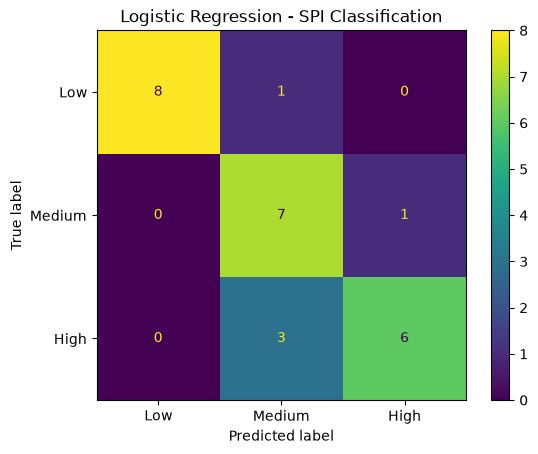

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred_logistic,
    labels=["Low", "Medium", "High"]
)

plt.title("Logistic Regression - SPI Classification")
plt.show()

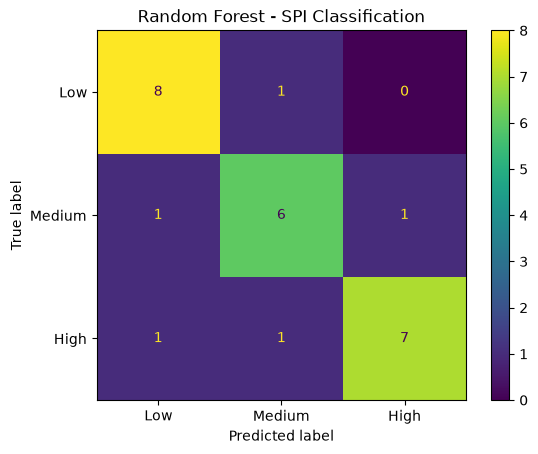

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred_rf,
    labels=["Low", "Medium", "High"]
)

plt.title("Random Forest - SPI Classification")
plt.show()

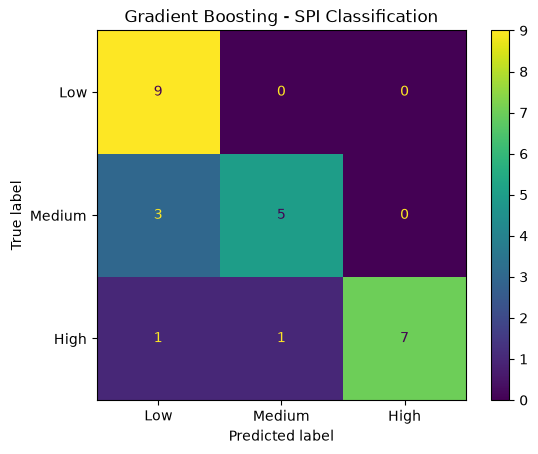

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred_gb,
    labels=["Low", "Medium", "High"]
)

plt.title("Gradient Boosting - SPI Classification")
plt.show()